In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import os
import warnings
warnings.filterwarnings("ignore")
 
BASE      = r"C:\Users\mukul\Desktop\Projects\patient-readmission-prediction"
DATA_PROC = os.path.join(BASE, "data", "processed")
MODELS    = os.path.join(BASE, "models")
REPORTS   = os.path.join(BASE, "reports")
 
os.makedirs(REPORTS, exist_ok=True)
 
sns.set_style("darkgrid")
plt.rcParams["figure.dpi"]     = 130
plt.rcParams["figure.figsize"] = (12, 5)
 
CYAN  = "#00e5ff"
RED   = "#ff4d6d"
GREEN = "#00f5a0"
AMBER = "#ffb347"
 
print("Setup complete ✅")
 


Setup complete ✅


# Load trained XGBoost model

In [8]:
xgb          = joblib.load(os.path.join(MODELS, "xgboost_model.pkl"))
feature_cols = joblib.load(os.path.join(MODELS, "feature_columns.pkl"))
 
print(f"Model loaded   : XGBoost ✅")
print(f"Features       : {len(feature_cols)}")
 
# Load processed data
df = pd.read_csv(os.path.join(DATA_PROC, "patient_processed.csv"))
 
TARGET = "readmitted_30_days"
X      = df[feature_cols]
y      = df[TARGET]
 
print(f"Dataset loaded : {X.shape[0]:,} patients × {X.shape[1]} features")
print(f"Readmission    : {y.mean():.1%}")
 
# Use a sample for faster SHAP computation
X_sample = X.sample(1000, random_state=42).reset_index(drop=True)
y_sample = y.loc[X_sample.index].reset_index(drop=True)
 
print(f"\nUsing sample of {len(X_sample):,} patients for SHAP")
 

Model loaded   : XGBoost ✅
Features       : 34
Dataset loaded : 10,000 patients × 34 features
Readmission    : 32.2%

Using sample of 1,000 patients for SHAP


# 2. Compute SHAP Values

In [9]:
print("Computing SHAP values... (this takes ~30 seconds)")
 
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)
 
print(f"SHAP values shape : {shap_values.shape}")
print(f"Expected value    : {explainer.expected_value:.4f}")
print("SHAP values computed ✅")

Computing SHAP values... (this takes ~30 seconds)
SHAP values shape : (1000, 34)
Expected value    : 0.0078
SHAP values computed ✅


# 3. Global Feature Importance (Bar Plot)
##### Shows which features have the MOST impact on predictions across ALL patients — on average.

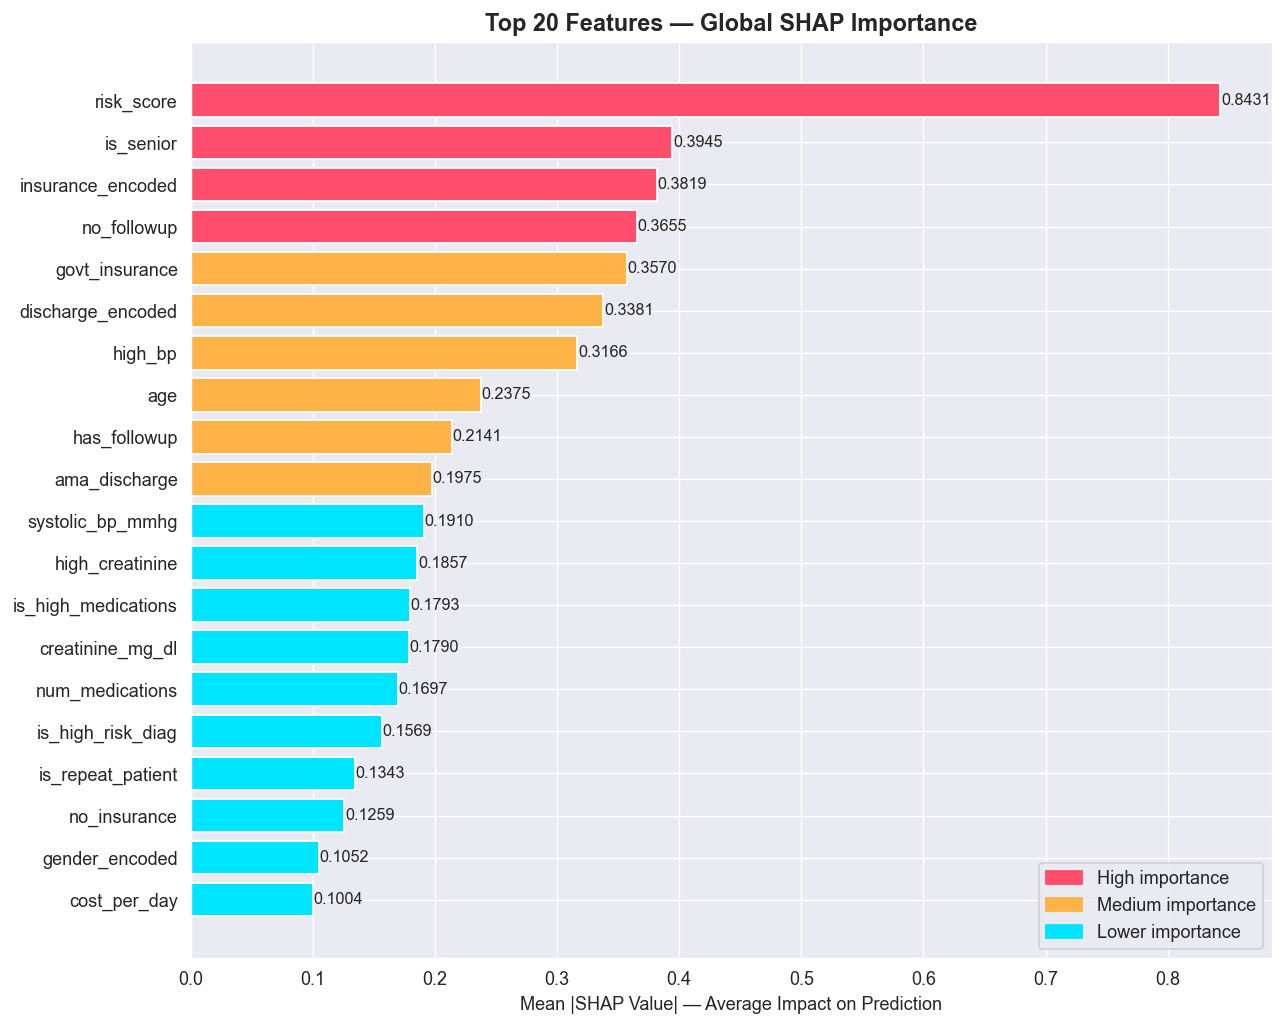


Top 10 most important features:
  risk_score                          0.8431
  is_senior                           0.3945
  insurance_encoded                   0.3819
  no_followup                         0.3655
  govt_insurance                      0.3570
  discharge_encoded                   0.3381
  high_bp                             0.3166
  age                                 0.2375
  has_followup                        0.2141
  ama_discharge                       0.1975


In [10]:
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=True).tail(20)
 
fig, ax = plt.subplots(figsize=(10, 8))
colors = [RED   if v > mean_shap.quantile(0.8) else
          AMBER if v > mean_shap.quantile(0.5) else
          CYAN  for v in mean_shap.values]
 
bars = ax.barh(mean_shap.index, mean_shap.values,
               color=colors, edgecolor="white")
ax.set_xlabel("Mean |SHAP Value| — Average Impact on Prediction")
ax.set_title("Top 20 Features — Global SHAP Importance", fontsize=13, fontweight="bold")
 
for bar, val in zip(bars, mean_shap.values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
 
legend = [
    mpatches.Patch(color=RED,   label="High importance"),
    mpatches.Patch(color=AMBER, label="Medium importance"),
    mpatches.Patch(color=CYAN,  label="Lower importance"),
]
ax.legend(handles=legend, loc="lower right")
 
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "16_shap_global_importance.png"), bbox_inches="tight")
plt.show()
 
print("\nTop 10 most important features:")
for feat, val in mean_shap.sort_values(ascending=False).head(10).items():
    print(f"  {feat:<35} {val:.4f}")
 

# 4. SHAP Beeswarm Plot
##### Shows BOTH the importance AND direction of each feature.
##### - Red dots = high feature value
##### - Blue dots = low feature value
##### - Right of center = pushes prediction toward READMISSION
##### - Left of center = pushes prediction away from readmission

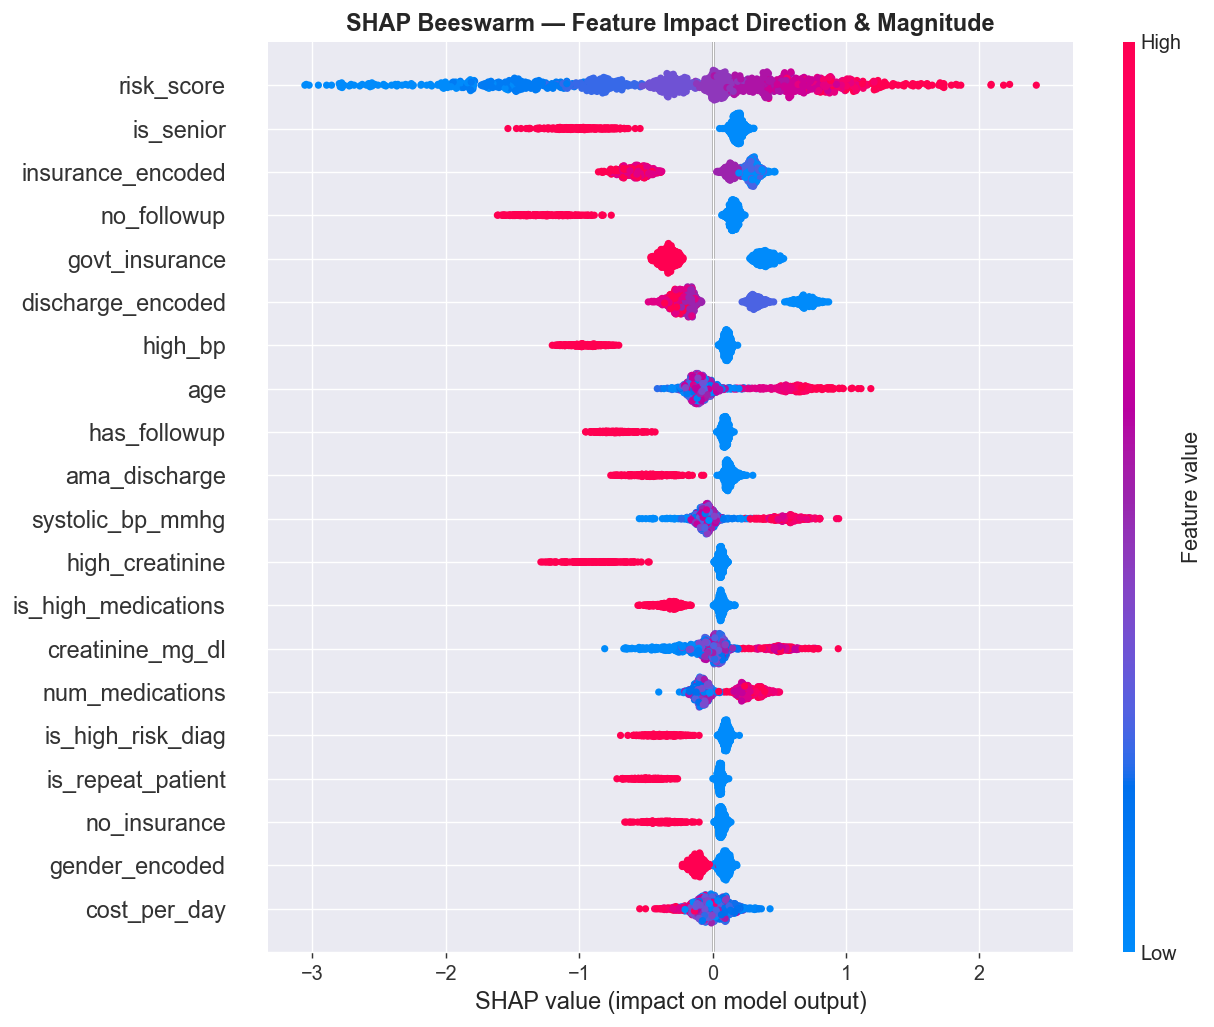

In [11]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    max_display = 20,
    show        = False,
    plot_size   = None
)
plt.title("SHAP Beeswarm — Feature Impact Direction & Magnitude",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "17_shap_beeswarm.png"), bbox_inches="tight")
plt.show()
 

# 5. SHAP Dependence Plots
##### Shows how a specific feature's value affects the prediction.

##### Top 4 features from global importance

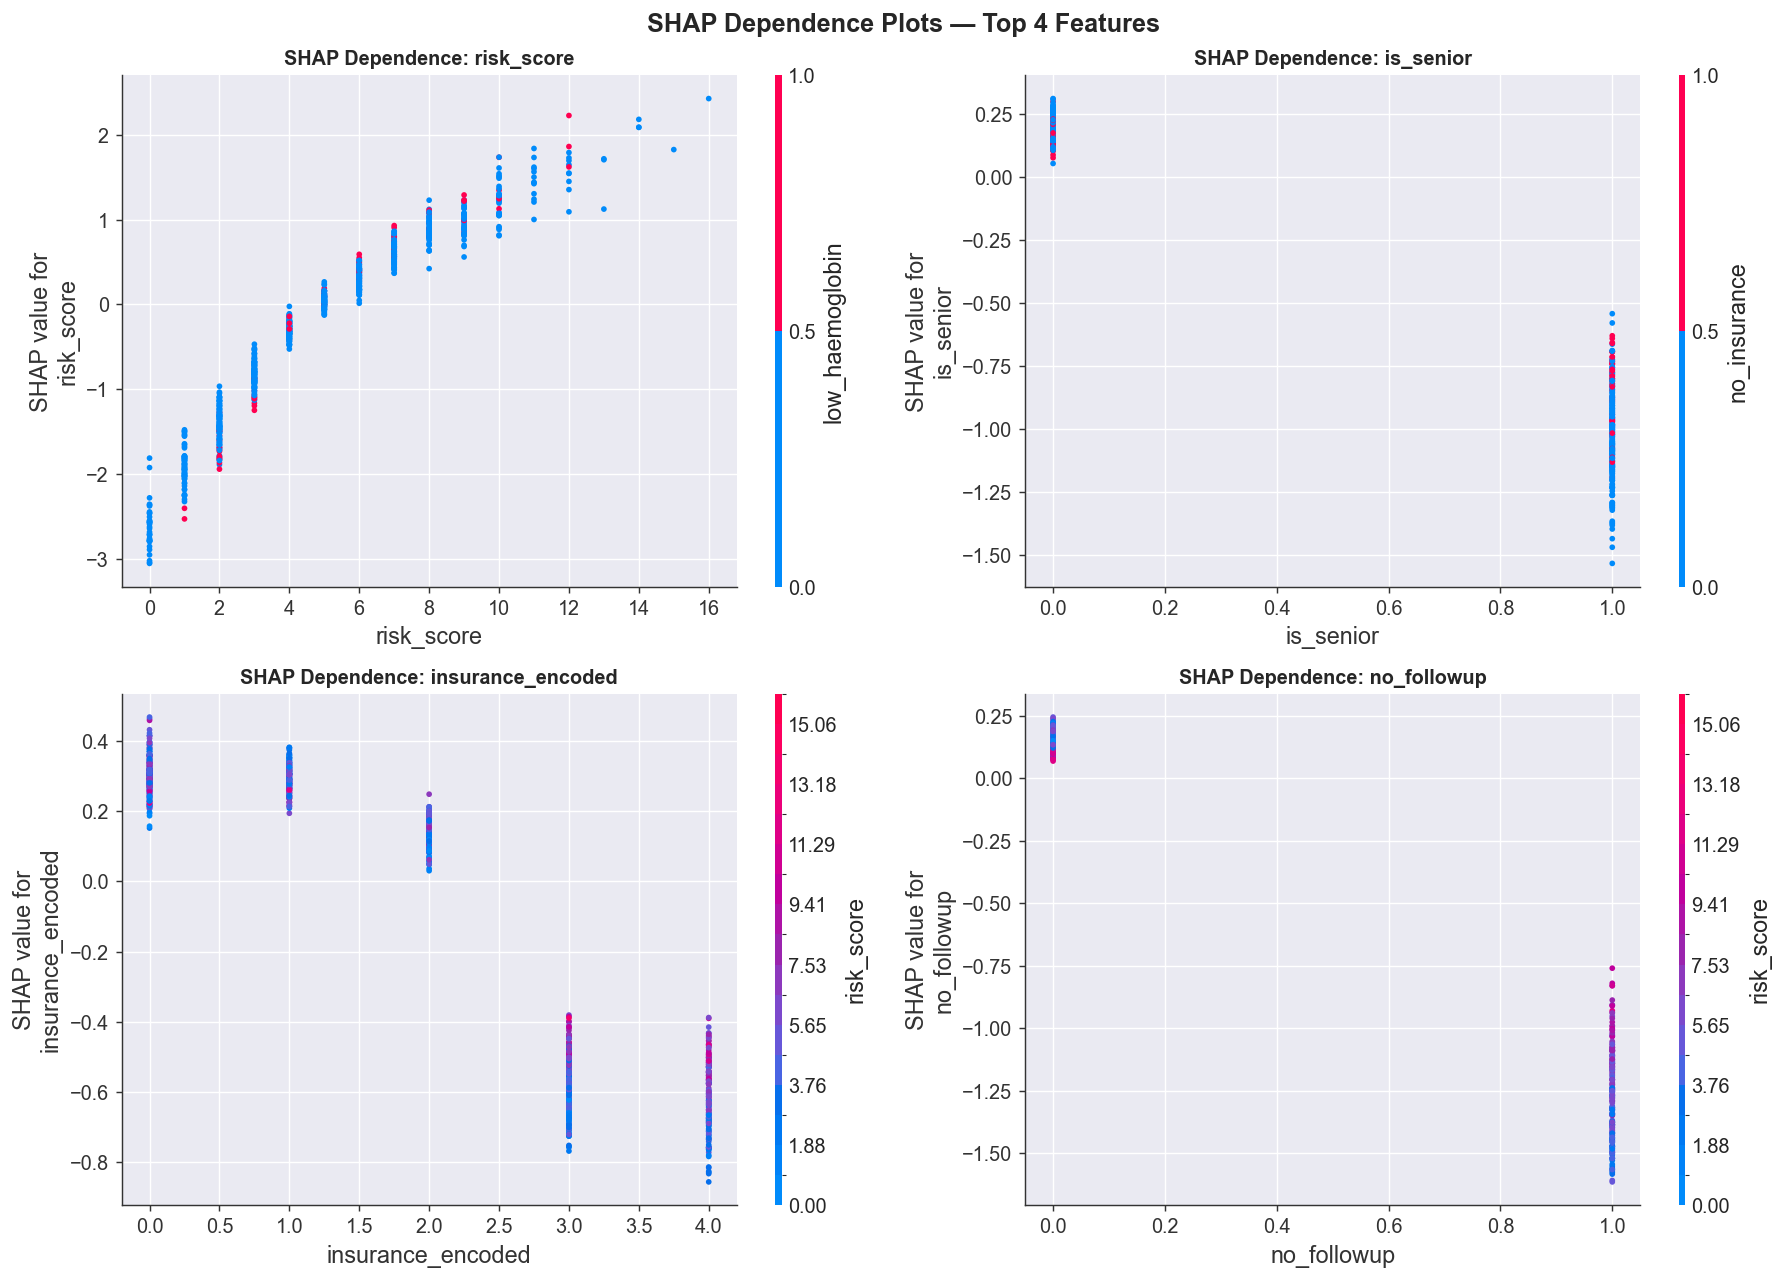

In [12]:
top_features = mean_shap.sort_values(ascending=False).head(4).index.tolist()
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
 
for i, feat in enumerate(top_features):
    shap.dependence_plot(
        feat,
        shap_values,
        X_sample,
        ax       = axes[i],
        show     = False,
        dot_size = 10
    )
    axes[i].set_title(f"SHAP Dependence: {feat}", fontsize=11, fontweight="bold")
 
plt.suptitle("SHAP Dependence Plots — Top 4 Features",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "18_shap_dependence.png"), bbox_inches="tight")
plt.show()
 

# 6. Individual Patient Explanation
##### Explains WHY the model flagged a SPECIFIC patient as high risk.

In [13]:
def explain_patient(patient_idx, label=""):
    patient    = X_sample.iloc[[patient_idx]]
    prob       = xgb.predict_proba(patient)[0][1]
    prediction = "⚠️ Will Readmit" if prob >= 0.45 else "✅ Will Not Readmit"
    risk       = "🔴 HIGH"   if prob >= 0.6 else \
                 "🟡 MEDIUM" if prob >= 0.3 else "🟢 LOW"
 
    print(f"\n{'='*55}")
    print(f"PATIENT EXPLANATION {label}")
    print(f"{'='*55}")
    print(f"Readmission Probability : {prob:.1%}")
    print(f"Prediction              : {prediction}")
    print(f"Risk Level              : {risk}")
    print(f"\nTop 8 features driving this prediction:")
 
    row_shap = pd.Series(shap_values[patient_idx], index=feature_cols)
    top_pos  = row_shap.nlargest(4)
    top_neg  = row_shap.nsmallest(4)
 
    print("\n  Pushing TOWARD readmission (+):")
    for feat, val in top_pos.items():
        feat_val = patient[feat].values[0]
        print(f"    {feat:<35} SHAP: +{val:.4f}  (value: {feat_val})")
 
    print("\n  Pushing AWAY from readmission (-):")
    for feat, val in top_neg.items():
        feat_val = patient[feat].values[0]
        print(f"    {feat:<35} SHAP: {val:.4f}  (value: {feat_val})")
 
    return prob
 
# Find a HIGH RISK patient
high_risk_idx = np.where(
    xgb.predict_proba(X_sample)[:, 1] >= 0.6
)[0]
if len(high_risk_idx) > 0:
    prob1 = explain_patient(high_risk_idx[0], "— HIGH RISK EXAMPLE")
 
# Find a LOW RISK patient
low_risk_idx = np.where(
    xgb.predict_proba(X_sample)[:, 1] < 0.3
)[0]
if len(low_risk_idx) > 0:
    prob2 = explain_patient(low_risk_idx[0], "— LOW RISK EXAMPLE")
 


PATIENT EXPLANATION — HIGH RISK EXAMPLE
Readmission Probability : 65.2%
Prediction              : ⚠️ Will Readmit
Risk Level              : 🔴 HIGH

Top 8 features driving this prediction:

  Pushing TOWARD readmission (+):
    age                                 SHAP: +0.6587  (value: 74)
    risk_score                          SHAP: +0.4653  (value: 6)
    govt_insurance                      SHAP: +0.3500  (value: 0)
    num_medications                     SHAP: +0.2739  (value: 8)

  Pushing AWAY from readmission (-):
    is_senior                           SHAP: -0.8719  (value: 1)
    insurance_encoded                   SHAP: -0.5412  (value: 4)
    no_insurance                        SHAP: -0.3749  (value: 1)
    is_high_medications                 SHAP: -0.2986  (value: 1)

PATIENT EXPLANATION — LOW RISK EXAMPLE
Readmission Probability : 27.7%
Prediction              : ✅ Will Not Readmit
Risk Level              : 🟢 LOW

Top 8 features driving this prediction:

  Pushing TOWARD r

# 7. SHAP Waterfall Plot

##### Visual breakdown of one patient's prediction — how each feature contributed to push the score up or down from the baseline.

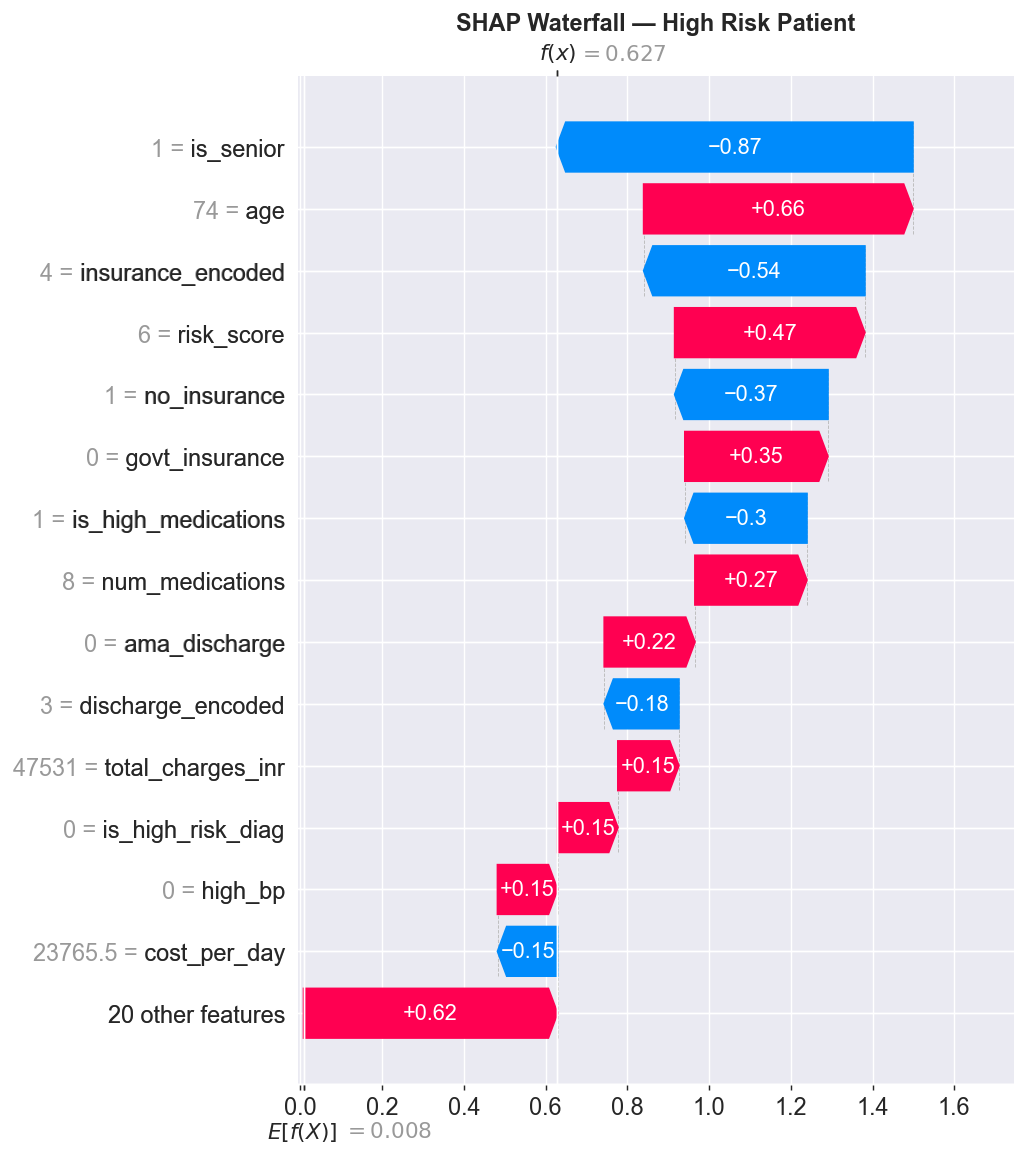

In [15]:
if len(high_risk_idx) > 0:
    idx = high_risk_idx[0]
 
    shap_exp = shap.Explanation(
        values          = shap_values[idx],
        base_values     = explainer.expected_value,
        data            = X_sample.iloc[idx].values,
        feature_names   = feature_cols
    )
 
    plt.figure(figsize=(10, 7))
    shap.waterfall_plot(shap_exp, max_display=15, show=False)
    plt.title("SHAP Waterfall — High Risk Patient", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS, "19_shap_waterfall_highrisk.png"), bbox_inches="tight")
    plt.show()
 

# 8. Key Clinical Insights from SHAP

In [16]:
print("=" * 60)
print("CLINICAL INSIGHTS FROM SHAP ANALYSIS")
print("=" * 60)
 
top10 = mean_shap.sort_values(ascending=False).head(10)
 
print("\nTop 10 features driving readmission predictions:")
for i, (feat, val) in enumerate(top10.items(), 1):
    print(f"  {i:>2}. {feat:<35} importance: {val:.4f}")
 
print("\nClinical interpretation:")
print("  → Features with high SHAP = model relies on them most")
print("  → Red dots right of center = high values increase risk")
print("  → Blue dots left of center = low values reduce risk")
print("  → Use these insights to guide retention interventions")
 
print(f"\n✅ SHAP Analysis Complete")
print(f"📁 Charts saved to: {REPORTS}")
print(f"\n🚀 Next Step: Connect model to Streamlit app (Notebook 05)")
 

CLINICAL INSIGHTS FROM SHAP ANALYSIS

Top 10 features driving readmission predictions:
   1. risk_score                          importance: 0.8431
   2. is_senior                           importance: 0.3945
   3. insurance_encoded                   importance: 0.3819
   4. no_followup                         importance: 0.3655
   5. govt_insurance                      importance: 0.3570
   6. discharge_encoded                   importance: 0.3381
   7. high_bp                             importance: 0.3166
   8. age                                 importance: 0.2375
   9. has_followup                        importance: 0.2141
  10. ama_discharge                       importance: 0.1975

Clinical interpretation:
  → Features with high SHAP = model relies on them most
  → Red dots right of center = high values increase risk
  → Blue dots left of center = low values reduce risk
  → Use these insights to guide retention interventions

✅ SHAP Analysis Complete
📁 Charts saved to: C:\Users\